# 07 — Feature Aggregation: Final Merge
**Tujuan:** Menggabungkan semua output feature engineering menjadi satu file `features_merged.csv` yang siap digunakan oleh semua model.  
**Input:** `data/processed/features_*.csv`  
**Output:** `data/processed/features_merged.csv`

| File Input | Fitur |
|------------|-------|
| features_growth.csv | growth, viral, age, temporal |
| features_engagement.csv | like, comment, retention, engagement |
| features_ctr.csv | ctr, impressions, conversion |
| features_time_decay.csv | rolling, ema, anomaly-prep |
| features_revenue.csv | revenue, monetization |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# ── 1. LOAD SEMUA FEATURE FILES ──────────────────────────────────────────────
BASE = '../../data/processed/'

files = {
    'growth':     'features_growth.csv',
    'engagement': 'features_engagement.csv',
    'ctr':        'features_ctr.csv',
    'time_decay': 'features_time_decay.csv',
    'revenue':    'features_revenue.csv',
}

dfs = {}
for name, fname in files.items():
    path = BASE + fname
    if os.path.exists(path):
        dfs[name] = pd.read_csv(path)
        print(f"✅ {name:12s}: {dfs[name].shape}")
    else:
        print(f"❌ MISSING: {path}")

✅ growth      : (2355, 20)
✅ engagement  : (2355, 9)
✅ ctr         : (2355, 7)
✅ time_decay  : (2355, 15)
✅ revenue     : (2355, 11)


In [3]:
# ── 2. MERGE SEMUA BERDASARKAN video_id ──────────────────────────────────────
df_merged = dfs['growth']
for name in ['engagement', 'ctr', 'time_decay', 'revenue']:
    if name in dfs:
        # Drop duplicate columns that already exist in df_merged, except video_id
        cols_to_drop = [c for c in dfs[name].columns if c in df_merged.columns and c != 'video_id']
        df_to_merge = dfs[name].drop(columns=cols_to_drop)
        df_merged = df_merged.merge(df_to_merge, on='video_id', how='outer')
        print(f"After merge {name}: {df_merged.shape}")

# Hapus kolom duplikat jika ada
df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]

print(f"\nTotal shape setelah merge: {df_merged.shape}")
print(f"Jumlah kolom: {len(df_merged.columns)}")

After merge engagement: (2355, 28)
After merge ctr: (2355, 34)
After merge time_decay: (2355, 46)
After merge revenue: (2355, 56)

Total shape setelah merge: (2355, 56)
Jumlah kolom: 56


In [4]:
# ── 3. HANDLE MISSING VALUES ─────────────────────────────────────────────────
missing_before = df_merged.isnull().sum()
missing_cols   = missing_before[missing_before > 0]
if len(missing_cols) > 0:
    print(f"Kolom dengan missing values ({len(missing_cols)} kolom):")
    print(missing_cols.to_string())
else:
    print("Tidak ada missing values ✓")

# Fill numeric columns with 0
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns
df_merged[numeric_cols] = df_merged[numeric_cols].fillna(0)

print(f"\nMissing after fill: {df_merged.isnull().sum().sum()}")

Kolom dengan missing values (1 kolom):
peak_views    5

Missing after fill: 0


In [5]:
# ── 4. EDA FINAL DATASET ─────────────────────────────────────────────────────
print("=== STATISTIK FINAL DATASET ===")
print(df_merged.describe().round(3).to_string())

=== STATISTIK FINAL DATASET ===


       growth_1_to_2  growth_2_to_3  growth_3_to_4  avg_growth_rate  growth_trend   peak_views  views_volatility  view_velocity  video_age_days  day_of_week     month  is_weekend  views_vs_channel_avg  is_viral  is_top_performer  subscriber_net  watch_time_hours  video_duration_sec        views  like_rate  dislike_rate  comment_rate  like_dislike_ratio  comment_engagement_ratio  retention_proxy  engagement_score  engagement_quality  impression_to_view_rate  ctr_normalized  ctr_impression_score  ctr_vs_channel_avg  impressions_log  ctr_category  rolling_avg_views  rolling_std_views  rolling_mean_views_7d  rolling_avg_views_15  ema_views_5  views_trend_ratio  rolling_cv_views  decay_weight  decayed_historical_views  views_pct_change  is_declining  views_deviation  revenue_per_view  revenue_per_subscriber  revenue_per_watchhour  adsense_share  premium_share  ad_impression_rate  monetization_efficiency  is_monetized  revenue_category  revenue_idr_log
count       2355.000       2355.000    

In [6]:
# ── 5. VALIDASI: COVERAGE PER MODEL ─────────────────────────────────────────
M1_FEATURES = [
    'growth_1_to_2','growth_2_to_3','growth_3_to_4','avg_growth_rate',
    'view_velocity','video_age_days','day_of_week','month','is_weekend',
    'is_viral','watch_time_hours','video_duration_sec',
    'like_rate','comment_rate','retention_proxy','engagement_score',
    'ctr_normalized','impression_to_view_rate','ctr_impression_score',
    'rolling_avg_views','ema_views_5','views_trend_ratio',
    'revenue_per_view','is_monetized'
]
M3_FEATURES = [
    'views','rolling_avg_views','rolling_mean_views_7d','views_pct_change',
    'views_vs_channel_avg','video_age_days','is_declining','views_deviation',
    'engagement_score','ctr_normalized','views_trend_ratio'
]
M5_FEATURES = [
    'avg_growth_rate','engagement_score','ctr_normalized',
    'retention_proxy','revenue_per_view','is_viral','is_monetized'
]

for model_name, feat_list in [('M1 Regression', M1_FEATURES),
                                ('M3 Anomaly',    M3_FEATURES),
                                ('M5 Clustering', M5_FEATURES)]:
    missing = [f for f in feat_list if f not in df_merged.columns]
    present = len(feat_list) - len(missing)
    status  = "✅" if not missing else "⚠️ "
    print(f"{status} {model_name}: {present}/{len(feat_list)} fitur tersedia")
    if missing:
        print(f"   MISSING: {missing}")

✅ M1 Regression: 24/24 fitur tersedia
✅ M3 Anomaly: 11/11 fitur tersedia
✅ M5 Clustering: 7/7 fitur tersedia


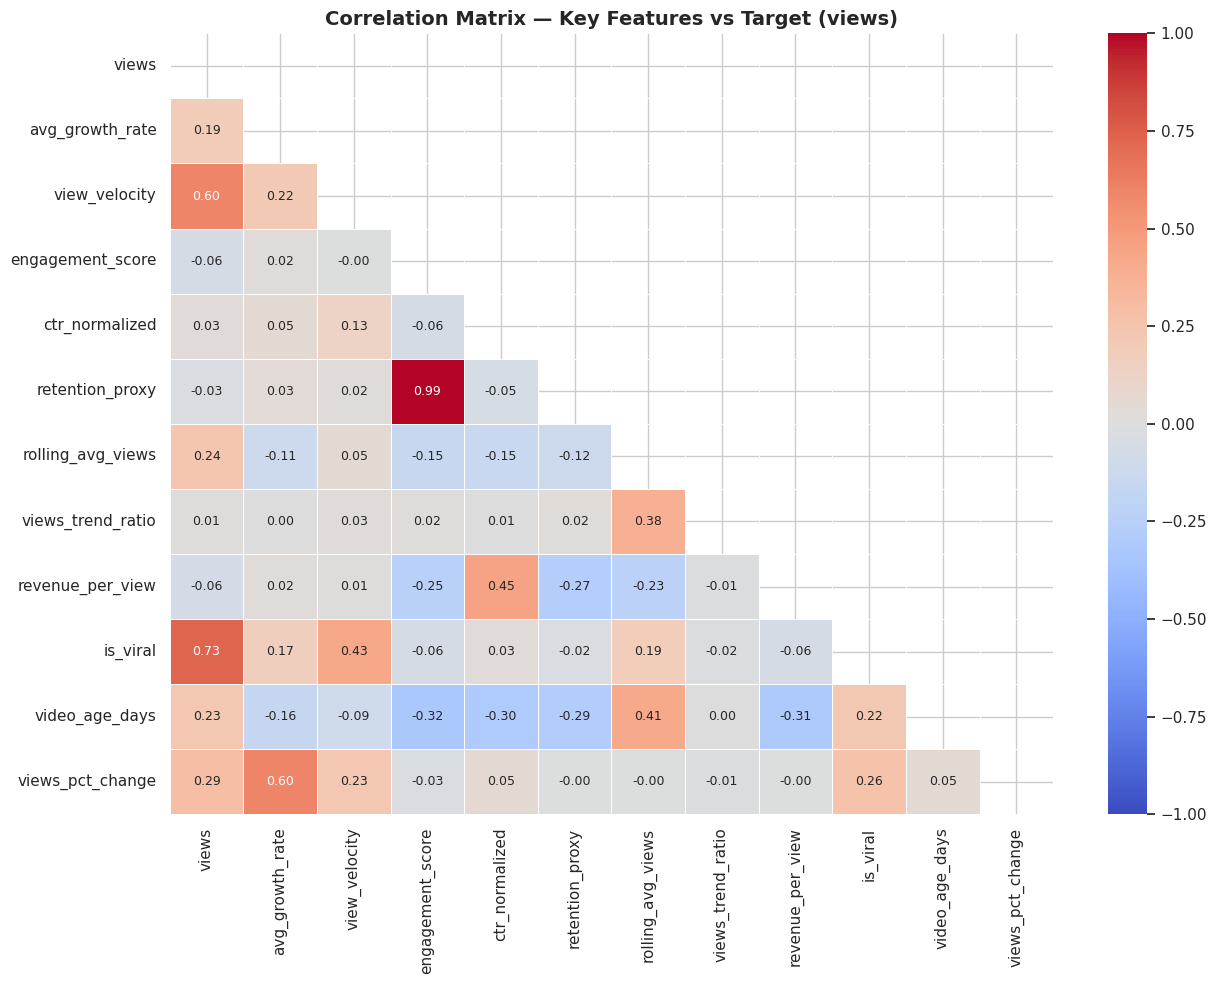

In [7]:
# ── 6. VISUALISASI: CORRELATION MATRIX FINAL ────────────────────────────────
key_features = [
    'views', 'avg_growth_rate', 'view_velocity', 'engagement_score',
    'ctr_normalized', 'retention_proxy', 'rolling_avg_views', 'views_trend_ratio',
    'revenue_per_view', 'is_viral', 'video_age_days', 'views_pct_change'
]
available = [f for f in key_features if f in df_merged.columns]

plt.figure(figsize=(13, 10))
corr = df_merged[available].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size':9}, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Key Features vs Target (views)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ── 7. EXPORT FINAL MERGED DATASET ──────────────────────────────────────────
output_path = '../../data/processed/features_merged.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_merged.to_csv(output_path, index=False)

print(f"✅ Final merged dataset tersimpan: {output_path}")
print(f"   Shape      : {df_merged.shape}")
print(f"   Total kolom: {len(df_merged.columns)}")
print(f"   Kolom lengkap:")
for i, c in enumerate(df_merged.columns, 1):
    print(f"   {i:3d}. {c}")

✅ Final merged dataset tersimpan: ../../data/processed/features_merged.csv
   Shape      : (2355, 56)
   Total kolom: 56
   Kolom lengkap:
     1. video_id
     2. growth_1_to_2
     3. growth_2_to_3
     4. growth_3_to_4
     5. avg_growth_rate
     6. growth_trend
     7. peak_views
     8. views_volatility
     9. view_velocity
    10. video_age_days
    11. day_of_week
    12. month
    13. is_weekend
    14. views_vs_channel_avg
    15. is_viral
    16. is_top_performer
    17. subscriber_net
    18. watch_time_hours
    19. video_duration_sec
    20. views
    21. like_rate
    22. dislike_rate
    23. comment_rate
    24. like_dislike_ratio
    25. comment_engagement_ratio
    26. retention_proxy
    27. engagement_score
    28. engagement_quality
    29. impression_to_view_rate
    30. ctr_normalized
    31. ctr_impression_score
    32. ctr_vs_channel_avg
    33. impressions_log
    34. ctr_category
    35. rolling_avg_views
    36. rolling_std_views
    37. rolling_mean_views_